# Multimode Fabry-Perot cavity: Linear spectra and 2D polariton dynamics

**Authors: Xinwei Ji, Tao E. Li**

This tutorial provides the simplest demonstration of the following two papers:

1. TE Li. Mesoscale Molecular Simulations of Fabry–Pérot Vibrational Strong Coupling. [J. Chem. Theory Comput. 20, 7016–7031 (2024).](https://pubs.acs.org/doi/10.1021/acs.jctc.4c00349)

2. Xinwei Ji, Tao E. Li. Nonlinear Freezing of Vibrational Polariton Transport via Mesoscale Simulations. arXiv:2606.27463 (2026).

This tutorial uses the `MultiModeSimulation` solver with many non-socket SHO drivers. The setup follows the simple 1D Fabry-Perot cavity parameters introduced in [JCTC 20, 7016–7031 (2024)](https://pubs.acs.org/doi/10.1021/acs.jctc.4c00349): 144 photon modes, 144 molecular grid points, `omega_perp = 2320 cm^-1`, and `delta_omega_x = 12.5 cm^-1`.


<img src="../media/demo_meoscale_cavmd.jpg" alt="Description" width="300">

The final part of this tutorial will try to simulate 2D polariton dynamics following the above setup.

## 1. 1D simulation with SHO model

The 144 molecular grid points are placed uniformly along the 1D cavity mirror plane. Each grid point carries one SHO driver in this toy example. 

The SHO dipoles are oriented along `y`, because the 1D cavity mode functions couple to the `y` polarization only in this specific cavity setting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from maxwelllink.tools.harmonic_oscillator_helper import MaxwellBoltzmannInitializer, LangevinThermostat

import maxwelllink as mxl
from maxwelllink.units import unit

# define parameters
rng = np.random.default_rng(seed=114514)
random_seed = rng.integers(1919810)
n_grid = 144
n_mode_x = 144

omega_perp_cm = 2320.0
delta_omega_x_cm = 12.5 
sho_frequency_cm = omega_perp_cm

coupling_strength = 2.5e-5
mu0 = 0.02
dt_fs = 0.5

# construct 144 molecules and a Fabry-Perot cavity
molecules = []
for _ in range(n_grid):
    molecules.append(
        mxl.Molecule(
            driver="sho",
            driver_kwargs={
                "omega": sho_frequency_cm*unit("cm_inv"),
                "mu0": mu0,
                "orientation": 1,
                "q_initial": 0.0,
                "p_initial": 0.0,
            },
            store_additional_data=False,
        )
    )

fbcavity = mxl.FabryPerotCavity(
        frequency_au=omega_perp_cm*unit("cm_inv"),
        coupling_strength=coupling_strength,
        coupling_axis="xy",
        n_grid_x=n_grid,
        y_grid_1d=[0.0],
        delta_omega_x_au=delta_omega_x_cm*unit("cm_inv"),
        delta_omega_y_au=0.0*unit("cm_inv"),
        n_mode_x=n_mode_x,
        n_mode_y=1,
)

sim = mxl.MultiModeSimulation(
    molecules=molecules,
    dt_au=dt_fs*unit("fs"),
    include_dse=True,
    cavity_geometry=fbcavity,
    initializer=MaxwellBoltzmannInitializer(temperature_au=300.0*unit("K"), random_seed=random_seed),
    thermostat=LangevinThermostat(temperature_au=300.0*unit("K"), dt_au=dt_fs*unit("fs"), tau_au=5000*unit("fs"), random_seed=random_seed)
)

sim.run(steps=int(20000/dt_fs),
        record_history=True,
        record_to_disk=False,
        record_every_steps=4,
        record_list=['qc'],)

[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket 

## 2. Linear polariton dispersion spectrum

Plot linear dispersion spectrum for photon coordinates along polarization direction `y`.

Text(0, 0.5, 'frequency [cm$^{-1}$]')

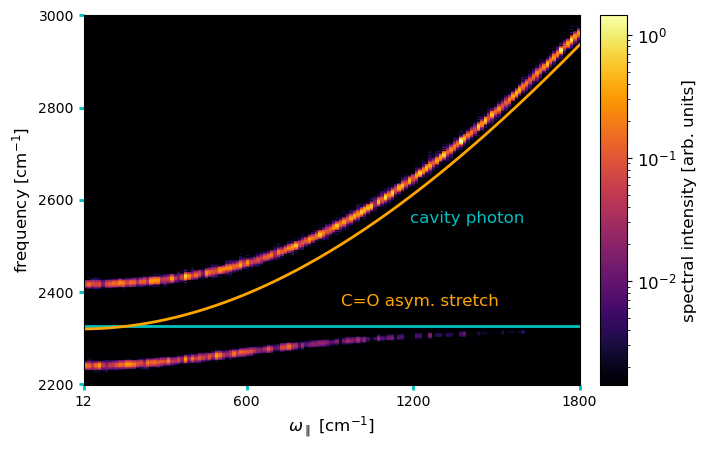

In [2]:
from maxwelllink.tools import ir_spectrum
from matplotlib.colors import LogNorm
from matplotlib import cm

fig, ax = plt.subplots()
sp_full = np.zeros((5000,144))
qc_history = np.array(sim.qc_history)[:, :, 1]
for i in range(144):
    x, sp_full[:,i] = ir_spectrum(qc_history[:,i], 2)
dx = x[2] - x[1]
nstart, nmid, nend = int(2200 / dx), int(2350 / dx), int(3000 / dx)
x = x[nstart:nend]
sp = np.abs(sp_full[nstart:nend,:]) / 1e32
sp = sp[::-1, :]
freq_cav_inplane_min = 12.5
freq_cav_inplane_max = 12.5 * 144
extent = [freq_cav_inplane_min, freq_cav_inplane_max, x[0] , x[-1]]

vmax = np.max(np.max(sp))
vmin = vmax * 0.001
pos = ax.imshow(sp, aspect='auto', extent=extent,
        cmap=cm.inferno,
        interpolation='nearest',
        norm=LogNorm(vmin=vmin, vmax=vmax)
        )
cbar_ax = ax.inset_axes([1.04, 0.0, 0.055, 1.0])
cbar = fig.colorbar(pos, cax=cbar_ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("spectral intensity [arb. units]", fontsize=12)

freq_cav_inplane = np.linspace(freq_cav_inplane_min, freq_cav_inplane_max, x.size)
plt.plot(freq_cav_inplane, np.ones(len(freq_cav_inplane)) * 2327, color='c', linewidth=2)
plt.plot(freq_cav_inplane, (2320.0**2 + freq_cav_inplane**2)**0.5, color='orange', linewidth=2)
ax.text(1190, 2550, "cavity photon", color='c', fontsize=12)
ax.text(940, 2370, "C=O asym. stretch", color='orange', fontsize=12)
ax.tick_params(color='c', labelsize='medium', width=2)

ax.set_xticks([12.5,600,1200,1800])
ax.set_yticks([2200,2400,2600,2800,3000])
ax.set_xlabel(r"$\omega_{\parallel}$ [cm$^{-1}$]", fontsize=12)
ax.set_ylabel(r"frequency [cm$^{-1}$]", fontsize=12)

## 3. Simulated group velocity from linear spectra

According to Jaynes--Cummings (JC) model, the polariton frequencies are:
$$\omega_{\pm}=\frac{\omega_{0}+\omega_{k}}{2}\pm\sqrt{\Delta^{2}+\frac{(\omega_{0}-\omega_{k})^{2}}{4}},$$
where $\omega_0$ and $\Delta$ represent the molecular vibrational frequency and coupling strength in the unit of frequency, respectively. $\omega_{k}$ denotes the cavity frequency of each cavity mode. The group velocity $v_g^{\pm}$ ($-$ and $+$ denote the LP and UP, respectively) corresponding to each cavity mode becomes:
$$\begin{aligned}
v_g^{\pm}&=\frac{\mathrm{d}\omega_{\pm}}{\mathrm{d}\mathbf{k}_{\parallel}}=\frac{\mathrm{d}\omega_{\pm}}{\mathrm{d}\omega_k}\cdot\frac{\mathrm{d}\omega_k}{\mathrm{d}\mathbf{k}_{\parallel}}\\
&=c\left(\frac{1}{2}\pm\frac{\omega_{k}-\omega_{0}}{4\sqrt{\Delta^{2}+\frac{(\omega_{0}-\omega_{k})^{2}}{4}}}\right)\cdot\frac{\mathbf{k}_\parallel}{\sqrt{\left(\frac{\pi}{L_z}\right)^2+\mathbf{k}_\parallel^2}}\\
&=c\left(\frac{1}{2}+\frac{\omega_{k}-\omega_{0}}{4\omega_{\pm}-2\omega_{0}-2\omega_{k}}\right)\cdot\frac{\omega_\parallel}{\omega_{k}},
\end{aligned}$$
where $c$ denotes the speed of light in the material medium. To simplify the plotting coefficient, we defined the dimensionless group velocity $\tilde{v}_g$:
$$\tilde{v}_g^{\pm}=\frac{1}{c}v_g^{\pm}=\frac{\mathrm{d}\omega_{\pm}}{\mathrm{d}\omega_{\parallel}}=\left(\frac{1}{2}+\frac{\omega_{k}-\omega_{0}}{4\omega_{\pm}-2\omega_{0}-2\omega_{k}}\right)\cdot\frac{\omega_\parallel}{\omega_{k}}$$

The figure below plots the analytical group velocity corresponding to the above dispersion relation.

group velocity of upper polariton at 450 cm^-1:  0.116023088435644
group velocity of lower polariton at 450 cm^-1:  0.07039041726093086


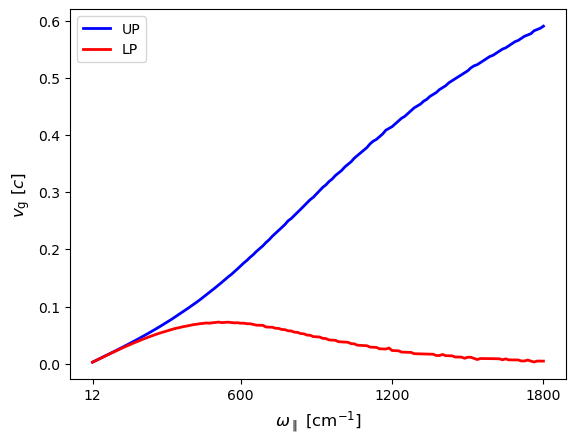

In [3]:
fig, ax = plt.subplots()
lp = np.array([x[np.argmax(sp_full[nstart:nmid, i])] for i in range(n_mode_x)])
up = np.array([x[nmid - nstart + np.argmax(sp_full[nmid:nend, i])] for i in range(n_mode_x)])

omega_0 = 2320
lp, up = lp.reshape(-1), up.reshape(-1)
wp = np.linspace(12.5, 12.5*144, 144)
wk = (omega_0**2 + wp**2)**0.5
vg_up = (0.5 + (wk - omega_0) / (4 * up - 2 * wk - 2 * omega_0)) * (wp / wk)
vg_lp = (0.5 + (wk - omega_0) / (4 * lp - 2 * wk - 2 * omega_0)) * (wp / wk)
wc_p = (up - omega_0) / (2 * up - omega_0 - wk)
plt.plot(wp, vg_up, color='b', linewidth=2, label="UP")
plt.plot(wp, vg_lp, color='r', linewidth=2, label="LP")
plt.legend()
ax.set_xticks([12.5,600,1200,1800])
ax.set_xlabel(r"$\omega_{\parallel}$ [cm$^{-1}$]", fontsize=12)
ax.set_ylabel(r"$v_{\rm g}$ $[c]$", fontsize=12)
print("group velocity of upper polariton at 450 cm^-1: ", vg_up[35])
print("group velocity of lower polariton at 450 cm^-1: ", vg_lp[35])

## 4. 2D imaging of polariton transport 

The following work uses MaxwellLink coupled to aproximately 20,000 LAMMPS MD drivers coupled to a 2D multimode cavity for simulating polariton transport dynamics on a 144*144 grid.

2. Xinwei Ji, Tao E. Li. Nonlinear Freezing of Vibrational Polariton Transport via Mesoscale Simulations. arXiv:2606.27463 (2026).

While this 2D simulation is too expensive to run on a local machine, below we provide a significantly simplified model for 2D polariton dynamics.

Here, 36*36 molecular grid points are placed uniformly in the 2D cavity mirror plane. Each grid point carries one SHO driver as a toy example for the molecular driver. A Gaussian pulse excites the UP frequency of a local hotspot at a particular in-plane k value, thus inducing **UP transport**.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from maxwelllink.tools.harmonic_oscillator_helper import MaxwellBoltzmannInitializer, LangevinThermostat
from maxwelllink.tools import gaussian_pulse, k_parallel_pulse

import maxwelllink as mxl
from maxwelllink.units import unit

# define parameters
rng = np.random.default_rng(seed=114514)
random_seed = rng.integers(1919810)
n_grid_x = 36
n_grid_y = 36
n_grid = n_grid_x * n_grid_y
n_mode_x = 36
n_mode_y = 36

omega_perp_cm = 2320.0
delta_omega_x_cm = 50.0
delta_omega_y_cm = 50.0
sho_frequency_cm = omega_perp_cm

coupling_strength = 5e-5 / np.sqrt(n_grid // 36)
mu0 = 0.02
dt_fs = 0.5

molecules = []
for _ in range(n_grid):
    molecules.append(
        mxl.Molecule(
            driver="sho",
            driver_kwargs={
                "omega": sho_frequency_cm*unit("cm_inv"),
                "mu0": mu0,
                "orientation": 1,
                "q_initial": 0.0,
                "p_initial": 0.0,
            },
            store_additional_data=False,
        )
    )

fbcavity = mxl.FabryPerotCavity(
        frequency_au=omega_perp_cm*unit("cm_inv"),
        coupling_strength=coupling_strength,
        coupling_axis="xy",
        n_grid_x=n_grid_x,
        n_grid_y=n_grid_y,
        delta_omega_x_au=delta_omega_x_cm*unit("cm_inv"),
        delta_omega_y_au=delta_omega_y_cm*unit("cm_inv"),
        n_mode_x=n_mode_x,
        n_mode_y=n_mode_y,
        # apply absorbing boundary conditions to the cavity modes to avoid reflections from the boundaries
        abc_cutoff=[0.1,0.1],
        save_mode_functions=True,
)

# define the temporal profile of the pulse, which is a Gaussian envelope
pulse_envelope = gaussian_pulse(
    amplitude_au=1.0,
    t0_au=0*unit("fs"),
    sigma_au=5e2*unit("fs"),
    t_start_au=0.0*unit("fs"),
    t_end_au=1e3*unit("fs"),
)

# define the k-space profile of the pulse along the mirror plane
molecule_source = k_parallel_pulse(
    cavity=fbcavity,
    # temporal profile of the pulse
    envelope=pulse_envelope,
    # frequency of the pulse, exciting the UP
    omega_au=2438.84*unit("cm_inv"),
    # the in-plane wavevector excited by this pulse. (kx, ky) both excited
    k_parallel_au=[9*50*unit("cm_inv"),50*unit("cm_inv")],
    direction="xy",
    # spatial center of the pulse acting on the mirror plane, in units of cavity length 
    center=(0.2, 0.5),
    # spatial size of the pulse hotspot, in units of cavity length 
    size=(0.2, 0.2),
    # excite cavity photon degrees of freedom instead of molecules
    target="photon",
    amplitude_au=0.05,
)

sim = mxl.MultiModeSimulation(
    molecules=molecules,
    dt_au=dt_fs*unit("fs"),
    include_dse=True,
    cavity_geometry=fbcavity,
    photon_pulse_drive=molecule_source,
    photon_pulse_axis= "y",
    photon_partial_charge=0.43,
    initializer=MaxwellBoltzmannInitializer(temperature_au=300.0*unit("K"), random_seed=random_seed),
    thermostat=LangevinThermostat(temperature_au=300.0*unit("K"), dt_au=dt_fs*unit("fs"), tau_au=5000*unit("fs"), random_seed=random_seed)
)

sim.run(steps=int(1521/dt_fs),
        record_history=True,
        record_to_disk=False,
        record_every_steps=40,
        record_list=['effective_efield'],)

[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket 

Finally, let's view the time-resolved EM field dynamics due to the pulse.

Note that as here we only have a single SHO for each grid point, the EM field experiences no dephasing, and the UP keeps transport ballistically. 

If realistic molecular drivers at condensed phases, such as LAMMPS MD engines, are used instead, **ballistic to diffusive turnover** of the UP transport will emerge.

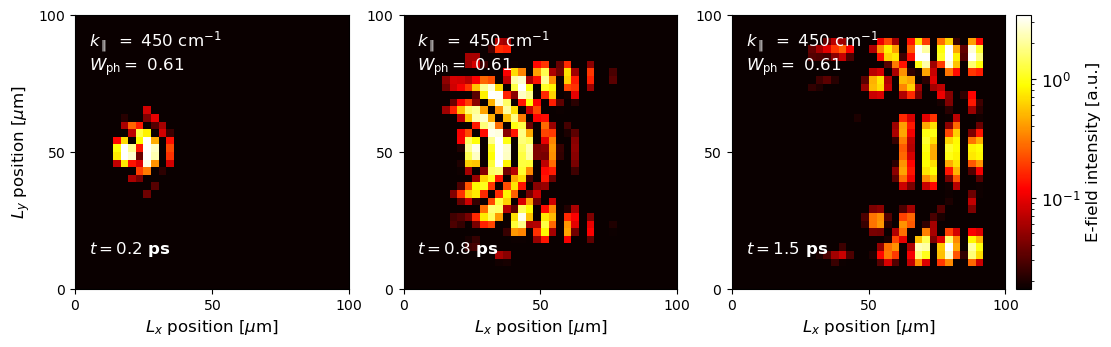

In [5]:
fig, axes = plt.subplots(1,3, figsize=(12,4))
time_list = [10, 38, 75]
time_labels = [r"$t=%.1f$ ps" % (t/50) for t in time_list]
data = np.abs(np.array(sim.effective_efield_history)[:,:,1].reshape(-1, 36, 36))**2
vmax = np.max(np.max(data[time_list[0],:,:]))
vmin = vmax * 0.005
for y0 in range(3):
    sp = (np.abs(data[time_list[y0], :]).reshape(36, 36))**2
    extent = [0 , 36, 0, 36]
    pos = axes[y0].imshow(sp, aspect='equal', extent=extent, origin="lower",
            cmap=cm.hot, interpolation='nearest',
            norm=LogNorm(vmin=vmin, vmax=vmax))
    axes[y0].set_box_aspect(1)
    axes[y0].set_yticks([0,18,36])
    axes[y0].set_yticklabels([r"$0$", r"$50$", r"$100$"])
    axes[y0].set_xticks([0,18,36])
    axes[y0].set_xticklabels([r"$0$", r"$50$", r"$100$"])
    axes[y0].text(0.05, 0.18, time_labels[y0], transform=axes[y0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left', color="w")
    axes[y0].set_xlabel(r"$L_x$ position [$\mu\rm{m}$]", fontsize=12)
    if y0 == 0: axes[y0].set_ylabel(r"$L_y$ position [$\mu\rm{m}$]", fontsize=12)

    if y0 == 2:
        cbar_ax = axes[y0].inset_axes([1.04, 0.0, 0.055, 1.0])
        cbar = fig.colorbar(pos, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=12)
        cbar.set_label("E-field intensity [a.u.]", fontsize=12)

for j in range(3):
    axes[j].text(0.05, 0.95, r"$k_{\parallel} \ =$"+rf"$ \ 450 \ $"+r"$\rm{cm}^{-1}$", transform=axes[j].transAxes, fontsize=12, fontweight='bold', va='top', ha='left', color="w")
    axes[j].text(0.05, 0.85, r"$W_{\rm ph}=$"+rf"$ \ 0.61 \ $", transform=axes[j].transAxes, fontsize=12, fontweight='bold', va='top', ha='left', color="w")
